# Kolmogorov-Arnold Network (KAN) para Explicabilidad
Aquí utilizaremos los embeddings (vectores fijos) recién generados para entrenar y visualizar un modelo KAN.

In [1]:
!pip install pandas

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from kan import KAN
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [3]:
train_embs = torch.load("train_embeddings.pt").to(device)
train_labels = torch.load("train_labels.pt").to(device)
test_embs = torch.load("test_embeddings.pt").to(device)
test_labels = torch.load("test_labels.pt").to(device)

print(f"Train embeddings: {train_embs.shape}")

Train embeddings: torch.Size([60000, 16])


In [4]:
print("Inicializando modelo KAN [16 entradas, 5 ocultas, 10 salidas]")
model = KAN(width=[16, 5, 10], grid=5, k=3, seed=42).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

Inicializando modelo KAN [16 entradas, 5 ocultas, 10 salidas]
checkpoint directory created: ./model
saving model version 0.0


In [5]:
epochs = 20
batch_size = 500
n_samples = train_embs.shape[0]

print("Entrenando KAN...")
for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(n_samples)
    epoch_loss = 0.
    
    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = train_embs[indices], train_labels[indices]
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)

    epoch_loss /= n_samples
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

Entrenando KAN...
Epoch 1/20 - Loss: 0.6329
Epoch 5/20 - Loss: 0.1009
Epoch 10/20 - Loss: 0.0919
Epoch 15/20 - Loss: 0.0896
Epoch 20/20 - Loss: 0.0892


In [6]:
model.eval()
with torch.no_grad():
    test_output = model(test_embs)
    pred = test_output.argmax(dim=1, keepdim=True)
    correct = pred.eq(test_labels.view_as(pred)).sum().item()
    acc = correct / len(test_labels)
    print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 96.98%


Visualizando las conexiones...


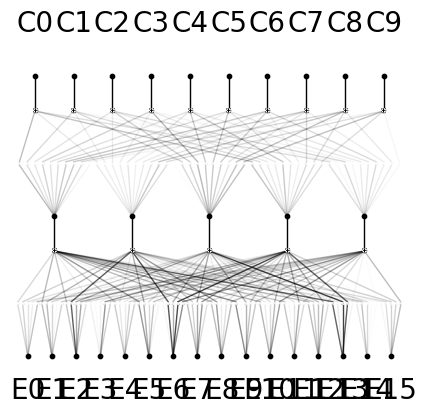

In [7]:
print("Visualizando las conexiones...")
model(test_embs)  # Forward pass necesario antes de graficar para registrar activaciones
model.plot(out_vars=[f"C{i}" for i in range(10)], in_vars=[f"E{i}" for i in range(16)])
plt.show()

### 1. Poda del Modelo (Pruning)
La poda es indispensable antes de pasar a representaciones simbólicas. Esto limpia las conexiones muertas y deja solo las funciones matemáticas estrictamente necesarias.

Aplicando poda (pruning)...
saving model version 0.1
Modelo podado.


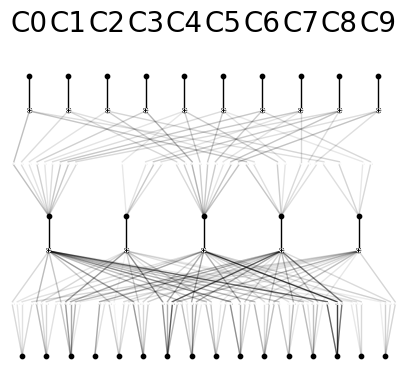

In [8]:
print("Aplicando poda (pruning)...")
# KAN recorta los nodos/aristas cuya activación promedio fue casi nula.
model = model.prune()
print("Modelo podado.")

# Volvemos a visualizar el modelo podado para comprobar qué tan esparso quedó
model(test_embs) # forward pass
model.plot(out_vars=[f"C{i}" for i in range(10)])


### 2. Regresión Simbólica
Aquí le pedimos a PyKAN que intente encajar funciones analíticas conocidas (seno, coseno, polinomio, etc.) en los B-Splines restantes.

In [9]:
print("Buscando representaciones simbólicas...")
# Le indicamos a KAN qué tipos de funciones intentar fittear
lib = ["x", "x^2", "x^3", "x^4", "exp", "log", "sqrt", "tanh", "sin", "tan", "abs"]
model.auto_symbolic(lib=lib)

print("¡Reemplazo simbólico completado!")

Buscando representaciones simbólicas...
fixing (0,0,0) with x, r2=0.7833864688873291, c=1
fixing (0,0,1) with x, r2=0.7539598941802979, c=1
fixing (0,0,2) with x, r2=0.6794662475585938, c=1
fixing (0,0,3) with 0
fixing (0,0,4) with x, r2=0.7560914754867554, c=1
fixing (0,1,0) with x, r2=0.5561953783035278, c=1
fixing (0,1,1) with x, r2=0.5716452598571777, c=1
fixing (0,1,2) with x, r2=0.5372763276100159, c=1
fixing (0,1,3) with 0
fixing (0,1,4) with x, r2=0.6579006314277649, c=1
fixing (0,2,0) with x, r2=0.9467130899429321, c=1
fixing (0,2,1) with x, r2=0.95169997215271, c=1
fixing (0,2,2) with x, r2=0.9504753351211548, c=1
fixing (0,2,3) with x, r2=0.9482666254043579, c=1
fixing (0,2,4) with x, r2=0.9367753267288208, c=1
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (0,3,2) with 0
fixing (0,3,3) with x, r2=0.7217451930046082, c=1
fixing (0,3,4) with x, r2=0.6702126264572144, c=1
fixing (0,4,0) with x, r2=0.8592649698257446, c=1
fixing (0,4,1) with x, r2=0.6362261772155762, c=1
fi

### 3. Extracción de la Fórmula
Veamos la fórmula matemática descubierta para una de las clases (por ejemplo, la clase 0 o 1).

In [12]:
import sympy

# 1. Creamos manualmente las 16 variables (E_1, E_2 ... E_16) usando Sympy para evitar el bug de pykan
mis_variables = [sympy.Symbol(f"E_{i}") for i in range(1, 17)]

# 2. Se las pasamos explícitamente a la función para que no use el exec() por dentro
formulas = model.symbolic_formula(var=mis_variables)[0]

print("Fórmula para predecir si es la clase 0:")
print(formulas[0])

print("\nFórmula para predecir si es la clase 1:")
print(formulas[1])


/home/daniel/Documentos/Cosas/Prueba_red_KAN/.venv/lib/python3.14/site-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


Fórmula para predecir si es la clase 0:
-0.262457861755496*E_1 - 0.437000389987888*E_10 + 0.273270843910692*E_11 + 0.300865843511251*E_12 + 0.0581028932295496*E_13 - 0.0260589496193044*E_14 - 0.0405238303038305*E_15 + 0.293227114693635*E_16 + 0.0371944081730288*E_2 - 0.019766716471885*E_3 - 0.143057669176701*E_4 - 0.311516594996576*E_5 + 0.447733356067471*E_6 + 0.262126354372773*E_7 - 0.136836942609011*E_8 + 0.0617711600862272*E_9 + 0.0126854605839406*(-0.803199827671051*E_9 - 6.37207984924316)**2 - 0.582663142000745

Fórmula para predecir si es la clase 1:
0.162812705713637*E_1 - 0.0494974333037468*E_10 - 0.335107166442205*E_11 + 0.0143108608046242*E_12 - 0.634947562445985*E_13 - 0.95321448013445*E_14 + 0.0876960350150456*E_15 + 0.00943117254464977*E_16 - 0.038625352605681*E_2 - 0.467124626457448*E_3 - 0.183707017908478*E_4 + 0.00972967901460534*E_5 - 0.186458360461402*E_6 + 0.260868818643854*E_7 - 0.162682672297414*E_8 - 0.0467675536984213*E_9 - 0.0109752789164915*(-0.803199827671051